In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("superstore_sales_cleaned.csv")
print(df.shape)

(9789, 20)


In [2]:
print(df.describe())

            Row ID   Postal Code         Sales  Shipping Duration  Order Month
count  9789.000000   9789.000000   9789.000000        9789.000000  9789.000000
mean   4896.705588  55273.322403    230.116193           3.961181     7.822658
std    2827.486899  32041.223413    625.302079           1.750452     3.277864
min       1.000000   1040.000000      0.444000           0.000000     1.000000
25%    2449.000000  23223.000000     17.248000           3.000000     5.000000
50%    4896.000000  58103.000000     54.384000           4.000000     9.000000
75%    7344.000000  90008.000000    210.392000           5.000000    11.000000
max    9800.000000  99301.000000  22638.480000           7.000000    12.000000


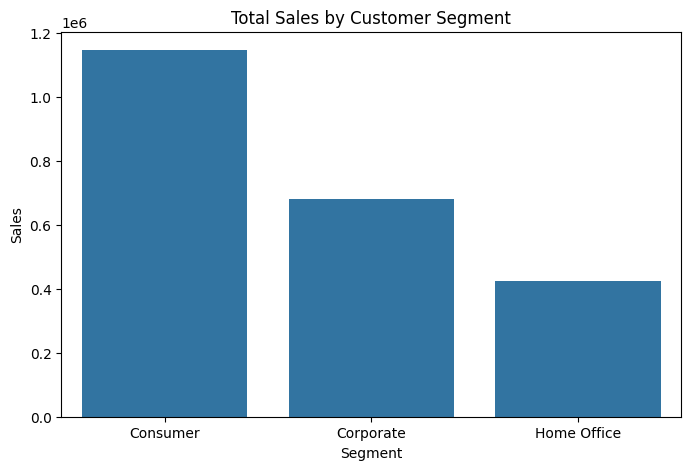

In [3]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum, errorbar=None)
plt.title("Total Sales by Customer Segment")
plt.show()

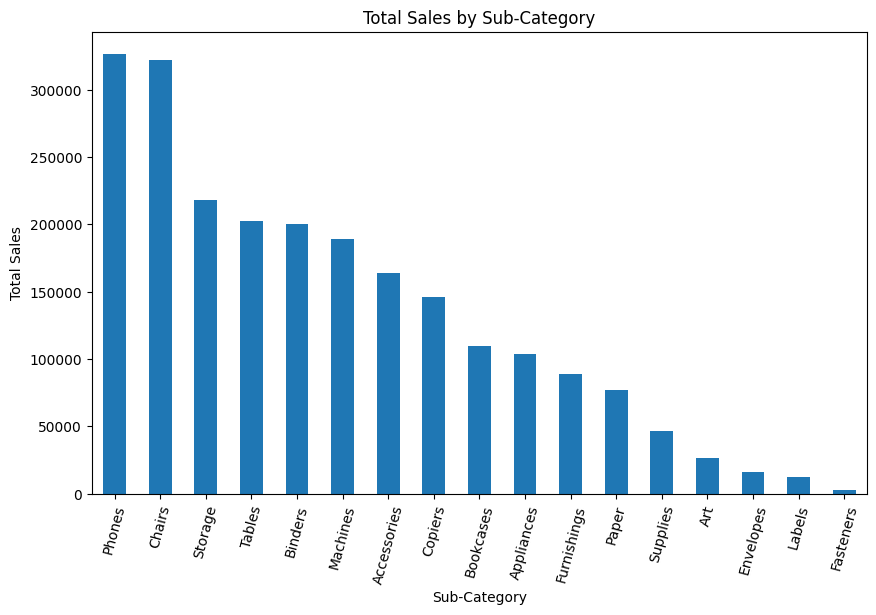

In [4]:
plt.figure(figsize=(10,6))
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcat_sales.plot(kind='bar')
plt.title("Total Sales by Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.show()

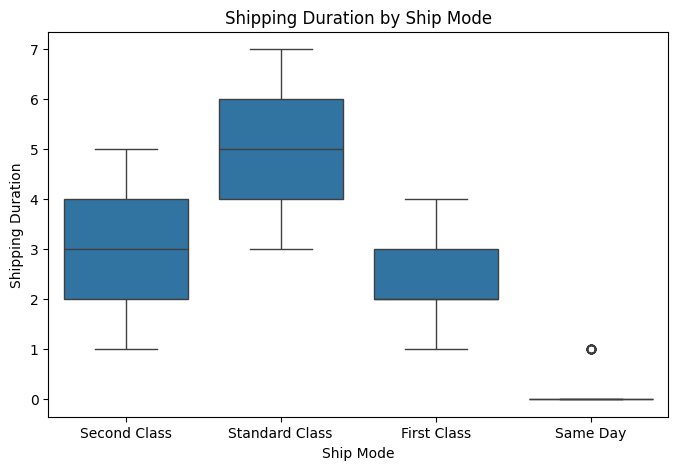

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Ship Mode', y='Shipping Duration', data=df)
plt.title("Shipping Duration by Ship Mode")
plt.show()

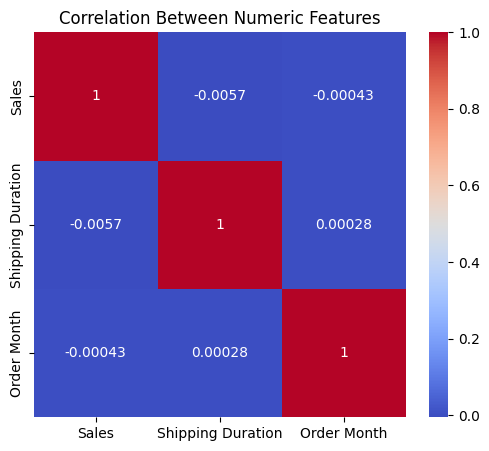

In [6]:
plt.figure(figsize=(6,5))
numeric_df = df[['Sales', 'Shipping Duration', 'Order Month']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

## Key Business Insights from EDA

1. **Consumer segment drives the majority of revenue** (~₹1.15M), generating nearly double the sales of Corporate and almost triple that of Home Office — suggesting marketing and inventory strategies should prioritize individual consumer needs.

2. **Phones and Chairs are the top-performing sub-categories**, each generating over ₹320K in sales, while Fasteners and Labels contribute minimally — indicating a small number of products drive the majority of revenue (a Pareto-like pattern worth investigating further).

3. **Shipping logistics are working as intended**: Same Day shipping consistently delivers within 0-1 days, while Standard Class takes the longest (4-7 days) — the clear, logical ordering across Ship Modes confirms data integrity and operational reliability.

4. **Sales amount shows virtually no correlation with Shipping Duration or Order Month** (correlation values near 0) — meaning faster shipping doesn't correlate with higher-value orders, and the time of year alone doesn't linearly predict sale size (even though total volume does spike seasonally, as seen in Day 7).

5. The gap between top and bottom Sub-Categories is stark — the top 3 sub-categories alone generate more revenue than the bottom 8 combined, highlighting an opportunity to either boost underperforming categories or focus resources on proven winners.